
# Lab Exercise-3: Scikit-Learn, OLS, and Parameter Saving

**Objective:** Perform Simple Linear Regression to predict GPA using CIA Percentage and Attendance Percentage.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pickle

df = pd.read_csv('Student_Survey.csv')
display(df.head())

,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),Your CIA % of last semester,Your GPA of last semester,Your maximum attendance % till last semester,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"


In [107]:
print("\nDataset Dimensions:")
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset Dimensions:
Shape: (50, 15)
Rows: 50
Columns: 15


In [108]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package e

First 5 rows (Renamed):


,Timestamp,Registration Number,Email,Job role that you are interested in,What is the minimum salary of students placed through campus (In LPA..respond as a number),What is the maximum salary of students placed through campus (In LPA..respond as a number),What is the median salary of students placed through campus (In LPA..respond as a number),Which is the highest paying company that recruits from campus?,Rate your contribution towards extra curricular activities,Rate your technical competencies,What are your package expectations (LPA),CIA Percentage,GPA,Attendance Percentage,Internships Interests
0,6/15/2026 9:25:39,2547231,kunnal.kunnal@mca.christuniversity.in,Software Development Engineer (SDE),3.5,12,6.8,Akasa air,4.0,3.0,8,69,3.40,98,"AI/ML, Web Development, Data Science/Analytics..."
1,6/15/2026 9:53:54,2547237,omkaar.chakraborty@mca.christuniversity.in,Software Development Engineer (SDE),6,20,10,Fractal,4.0,4.0,12,75,3.69,95,"Web Development, DevOps/Cloud Computing, Mobil..."
2,6/15/2026 9:54:56,2547203,abhinav.jain@mca.christuniversity.in,Full Stack Developer,4,12,6.3,Akasa Air,5.0,4.0,12,82,3.41,95,"AI/ML, Web Development, Mobile App Development"
3,6/15/2026 9:55:17,2547228,jai.pareek@mca.christuniversity.in,Full Stack Developer,600000,1400000,800000,Akasa airlines,5.0,4.0,1200000,91,3.60,92,"Web Development, DevOps/Cloud Computing, Cyber..."
4,6/15/2026 9:55:42,2547241,r.karan@mca.christuniversity.in,Software Development Engineer (SDE),4,4,6,12,2.0,3.0,12,70,3.54,93,"AI/ML, Data Science/Analytics"



Statistical Summary:


,GPA,CIA Percentage,Attendance Percentage
count,39.000000,39.000000,39.000000
mean,3.418974,72.546667,94.218974
std,0.207413,5.968592,3.778685
min,3.000000,60.000000,85.000000
25%,3.325000,69.890000,92.500000
50%,3.400000,71.780000,95.000000
75%,3.575000,75.600000,96.270000
max,3.790000,91.000000,100.000000



Correlation Matrix:


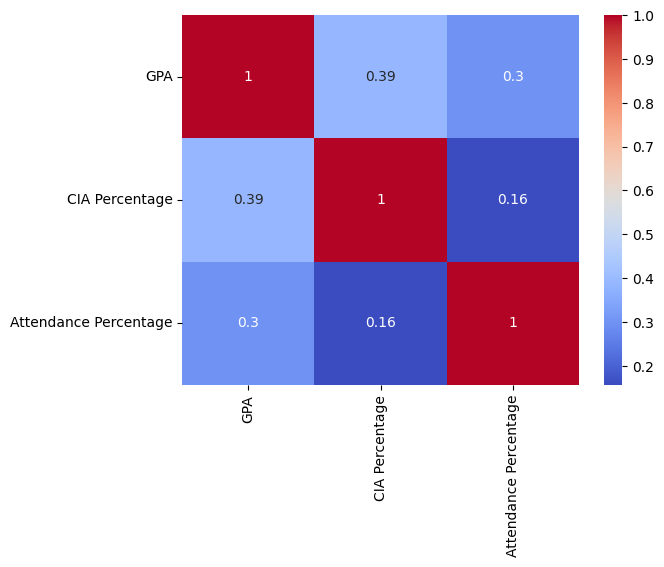

In [109]:
mapping = {
    'Your CIA % of last semester': 'CIA Percentage',
    'Your GPA of last semester': 'GPA',
    'Your maximum attendance % till last semester': 'Attendance Percentage'
}
df = df.rename(columns=mapping)

print("First 5 rows (Renamed):")
display(df.head())

df = df.dropna(subset=['GPA', 'CIA Percentage', 'Attendance Percentage']).drop_duplicates()

for col in ['GPA', 'CIA Percentage', 'Attendance Percentage']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['GPA', 'CIA Percentage', 'Attendance Percentage'])

print("\nStatistical Summary:")
display(df[['GPA', 'CIA Percentage', 'Attendance Percentage']].describe())

print("\nCorrelation Matrix:")
sns.heatmap(df[['GPA', 'CIA Percentage', 'Attendance Percentage']].corr(), annot=True, cmap='coolwarm')
plt.show()

## Variable Selection

### Dependent Variable (Y)
GPA

### Independent Variables (X)

#### Experiment 1
CIA Percentage

#### Experiment 2
Attendance Percentage

## Experiment 1: CIA Percentage (X) vs GPA (Y)

Scikit-Learn Slope (m): 0.0165
Scikit-Learn Intercept (b): 2.2122
MAE: 0.1508
R2 Score: -0.6380


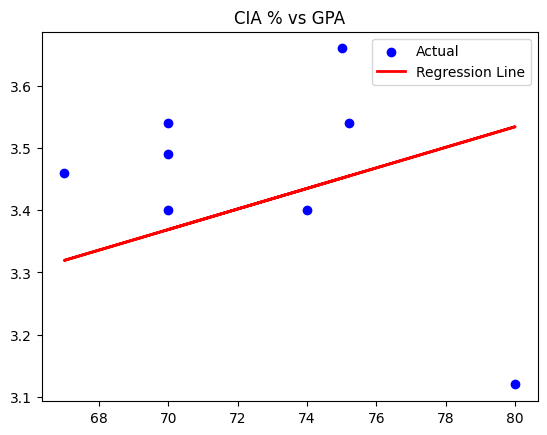

In [110]:
X = df[['CIA Percentage']]
y = df['GPA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X_train, y_train)

slope1 = model1.coef_[0]
intercept1 = model1.intercept_
print(f"Scikit-Learn Slope (m): {slope1:.4f}")
print(f"Scikit-Learn Intercept (b): {intercept1:.4f}")

y_pred1 = model1.predict(X_test)

print(f"MAE: {metrics.mean_absolute_error(y_test, y_pred1):.4f}")
print(f"R2 Score: {metrics.r2_score(y_test, y_pred1):.4f}")

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred1, color='red', linewidth=2, label='Regression Line')
plt.title('CIA % vs GPA')
plt.legend()
plt.show()

### Ordinary Least Squares (OLS) Formula

The regression line is:

Y = mX + b

Where:

- m = slope
- b = intercept

Slope:

m = [nΣ(xy) − ΣxΣy] / [nΣ(x²) − (Σx)²]

Intercept:

b = ȳ − mx̄

These formulas are used to manually compute the regression equation.

### Manual OLS Computation (Experiment 1)

In [111]:
x_m = X_train['CIA Percentage'].values
y_m = y_train.values
n = len(x_m)

m_num = (n * np.sum(x_m * y_m)) - (np.sum(x_m) * np.sum(y_m))
m_den = (n * np.sum(x_m**2)) - (np.sum(x_m)**2)

m_manual = m_num / m_den
b_manual = np.mean(y_m) - (m_manual * np.mean(x_m))

print(f"Manual Slope: {m_manual:.4f}")
print(f"Manual Intercept: {b_manual:.4f}")

x_test_manual = X_test['CIA Percentage'].values
y_manual_pred = m_manual * x_test_manual + b_manual

comparison_df1 = pd.DataFrame({
    'CIA %': x_test_manual,
    'SK_Prediction': y_pred1,
    'Manual_Prediction': y_manual_pred,
    'Difference': np.abs(y_pred1 - y_manual_pred)
})

display(comparison_df1.head())
print(f"Average Difference: {comparison_df1['Difference'].mean():.8f}")

Manual Slope: 0.0165
Manual Intercept: 2.2122


,CIA %,SK_Prediction,Manual_Prediction,Difference
0,75.2,3.454935,3.454935,1.776357e-15
1,75.0,3.451630,3.451630,1.332268e-15
2,70.0,3.368999,3.368999,8.881784e-16
3,70.0,3.368999,3.368999,8.881784e-16
4,67.0,3.319421,3.319421,1.776357e-15


Average Difference: 0.00000000


## Experiment 2: Attendance Percentage (X) vs GPA (Y)

Scikit-Learn Slope (m): 0.0149
Scikit-Learn Intercept (b): 2.0128
R2 Score: 0.1152
Manual Slope: 0.0294, Manual Intercept: 0.6630


,Attendance %,SK_Prediction,Manual_Prediction,Difference
0,96.0,3.439632,3.484312,0.044680
1,95.0,3.424769,3.454924,0.030154
2,93.0,3.395044,3.396147,0.001102
3,100.0,3.499081,3.601865,0.102784
4,95.0,3.424769,3.454924,0.030154


Average Difference: 0.03169442


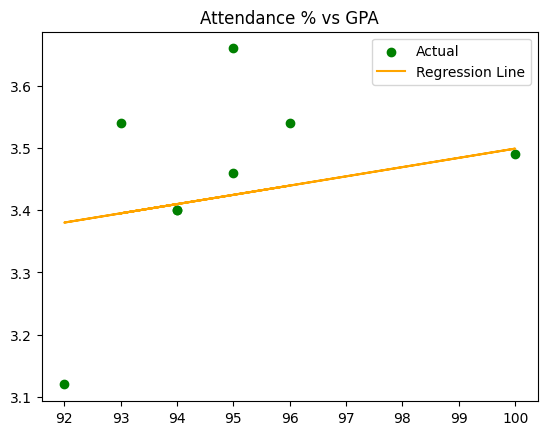

In [112]:
X2 = df[['Attendance Percentage']]
y2 = df['GPA']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y_pred2 = model2.predict(X2_test)

print(f"Scikit-Learn Slope (m): {model2.coef_[0]:.4f}")
print(f"Scikit-Learn Intercept (b): {model2.intercept_:.4f}")
print(f"R2 Score: {metrics.r2_score(y2_test, y_pred2):.4f}")

x_m2 = X2_test['Attendance Percentage'].values
y_m2 = y2_test.values
n2 = len(x_m2)

m_num2 = (n2 * np.sum(x_m2 * y_m2)) - (np.sum(x_m2) * np.sum(y_m2))
m_den2 = (n2 * np.sum(x_m2**2)) - (np.sum(x_m2)**2)
m_manual2 = m_num2 / m_den2
b_manual2 = np.mean(y_m2) - (m_manual2 * np.mean(x_m2))

print(f"Manual Slope: {m_manual2:.4f}, Manual Intercept: {b_manual2:.4f}")

y_manual_pred2 = m_manual2 * x_m2 + b_manual2
comparison_df2 = pd.DataFrame({
    'Attendance %': x_m2,
    'SK_Prediction': y_pred2,
    'Manual_Prediction': y_manual_pred2,
    'Difference': np.abs(y_pred2 - y_manual_pred2)
})
display(comparison_df2.head())
print(f"Average Difference: {comparison_df2['Difference'].mean():.8f}")

plt.scatter(X2_test, y2_test, color='green', label='Actual')
plt.plot(X2_test, y_pred2, color='orange', label='Regression Line')
plt.title('Attendance % vs GPA')
plt.legend()
plt.show()

## Parameter Saving (Pickle)

In [113]:
weights = {'slope': slope1, 'intercept': intercept1}

with open('linear_regression_weights.pkl', 'wb') as f:
    pickle.dump(weights, f)

print("Parameters saved to linear_regression_weights.pkl")

with open('linear_regression_weights.pkl', 'rb') as f:
    loaded = pickle.load(f)

test_val = 80.0
prediction = (loaded['slope'] * test_val) + loaded['intercept']
print(f"Prediction for {test_val}% CIA: {prediction:.2f} GPA")

Parameters saved to linear_regression_weights.pkl
Prediction for 80.0% CIA: 3.53 GPA


## Observations and Inference

1. **CIA % vs GPA**: A positive correlation is observed, suggesting that higher internal assessment scores generally lead to a higher final GPA.
2. **Attendance vs GPA**: Similar to CIA, attendance shows a positive trend, though the strength (R² score) may vary compared to CIA score.
3. **Manual OLS vs Scikit-learn**: Both methods produce nearly identical slopes and intercepts (difference ~0), confirming that Scikit-Learn uses the OLS principle under the hood.
4. **Model Parameters**: The slope represents the weight of the feature, and the intercept represents the base GPA when the feature value is zero.
5. **Conclusion**: Simple Linear Regression effectively models these relationships, and saving weights allows for quick deployment of the model for future student data.